# Encoding Categorical Features for ML Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Encode categorical features for ML models
- Use label encoding
- Use one-hot encoding
- Apply encoding techniques to datasets
- Understand when to use each method

## 🔗 Where this fits

**Builds on:** Unit 2, lesson 06 "Developing Simple Supervised and Unsupervised Learning Models" — those models only accept numbers, so text columns must be encoded.

**Used later in:** Course 04 (AIAT 114) — Unit 1 and Course 05 (AIAT 115) — Unit 2, where encoding becomes part of a full preprocessing pipeline.

---

This notebook covers practical activities from **Course 01, Unit 2**:
- Encoding categorical features for ML models

---

## Introduction

**Categorical encoding** converts categorical data into numerical format that machine learning models can process, using techniques like label encoding and one-hot encoding.


## 🎯 A category that should never have been a feature

Between 2005 and 2019 the Dutch tax administration ran a risk-classification
system over families claiming childcare benefits. Among the attributes it used
was **nationality**. Roughly **26,000 families** were wrongly accused of fraud and
ordered to repay allowances in full — often €20,000 to €60,000, with penalties,
and no payment plan. Families with roots in the former Dutch colonies were hit
hardest. A parliamentary inquiry called the treatment an "unprecedented
injustice", and in **January 2021 the Dutch government resigned** over it.

That scandal is about many things — oversight, appeal rights, the presumption of
guilt — and one of them is the subject of this notebook. Nationality is a
**nominal** attribute: a set of names with no order and no distance between them.
The moment it enters a model it has to be turned into numbers, and the choice of
how carries an implicit claim. Encode it as `0, 1, 2, ...` and you have told a
linear or distance-based model that these categories lie on a line, that one is
"greater" than another and that some pairs are closer than others. None of that
is true, and the model will use it anyway.

### What goes wrong without a deliberate encoding choice

Two failures, in this order. **The silent one:** the model treats invented order
as real structure and learns relationships that exist only in your integer
mapping. **The loud one:** you avoid that by one-hot encoding a column with
thousands of categories and your feature matrix explodes. This notebook shows
both effects on five rows, where you can count them by hand.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("montgomery_911_calls"), ...
# -------------------------------------------------------------------------------------

In [2]:
# Setup: a tiny DataFrame with three text columns. Models cannot consume strings, so
# this notebook shows the two standard ways to turn categories into numbers.
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

print("✅ Libraries imported!")
print("\nEncoding Categorical Features")
print("=" * 60)

# Sample categorical data
# Three categorical columns with different numbers of distinct values.
data = {
    'color': ['red', 'blue', 'green', 'red', 'blue'],
    'size': ['small', 'large', 'medium', 'small', 'large'],
    'category': ['A', 'B', 'A', 'C', 'B']
}

df = pd.DataFrame(data)
print("\nOriginal data:")
print(df)
print(f"\nData types:\n{df.dtypes}")

print("\n✅ Data prepared!")

✅ Libraries imported!

Encoding Categorical Features

Original data:
   color    size category
0    red   small        A
1   blue   large        B
2  green  medium        A
3    red   small        C
4   blue   large        B

Data types:
color       object
size        object
category    object
dtype: object

✅ Data prepared!


In [3]:
# Label encoding maps each category to an integer (blue=0, green=1, ...). Compact, but
# it invents an order — only safe for truly ordinal data or tree models.
# Label Encoding - Assigns integer labels
print("=" * 60)
print("LABEL ENCODING")
print("=" * 60)

label_encoder = LabelEncoder()

# Encode each categorical column
# Encode every text column and show the category -> integer mapping side by side.
for col in df.select_dtypes(include=['object']).columns:
    df[f'{col}_encoded'] = label_encoder.fit_transform(df[col])
    print(f"\n{col} encoding:")
    print(f"  Original: {df[col].unique()}")
    print(f"  Encoded: {df[f'{col}_encoded'].unique()}")

print("\n✅ Label encoding completed!")

LABEL ENCODING

color encoding:
  Original: ['red' 'blue' 'green']
  Encoded: [2 0 1]

size encoding:
  Original: ['small' 'large' 'medium']
  Encoded: [2 0 1]

category encoding:
  Original: ['A' 'B' 'C']
  Encoded: [0 1 2]

✅ Label encoding completed!


In [4]:
# One-hot encoding creates one binary column per category: no fake order, but the
# column count grows with the number of categories — the standard choice for nominal data.
# One-Hot Encoding - Creates binary columns
print("=" * 60)
print("ONE-HOT ENCODING")
print("=" * 60)

# Using pandas get_dummies
df_onehot = pd.get_dummies(df[['color', 'size', 'category']], prefix=['color', 'size', 'category'])
print("\nOne-hot encoded data:")
print(df_onehot)

# Compare column counts: 3 text columns became 9 binary ones — the cost of one-hot.
print(f"\nOriginal columns: {df[['color', 'size', 'category']].shape[1]}")
print(f"One-hot columns: {df_onehot.shape[1]}")

print("\n✅ One-hot encoding completed!")

ONE-HOT ENCODING

One-hot encoded data:
   color_blue  color_green  color_red  size_large  size_medium  size_small  \
0       False        False       True       False        False        True   
1        True        False      False        True        False       False   
2       False         True      False       False         True       False   
3       False        False       True       False        False        True   
4        True        False      False        True        False       False   

   category_A  category_B  category_C  
0        True       False       False  
1       False        True       False  
2        True       False       False  
3       False       False        True  
4       False        True       False  

Original columns: 3
One-hot columns: 9

✅ One-hot encoding completed!


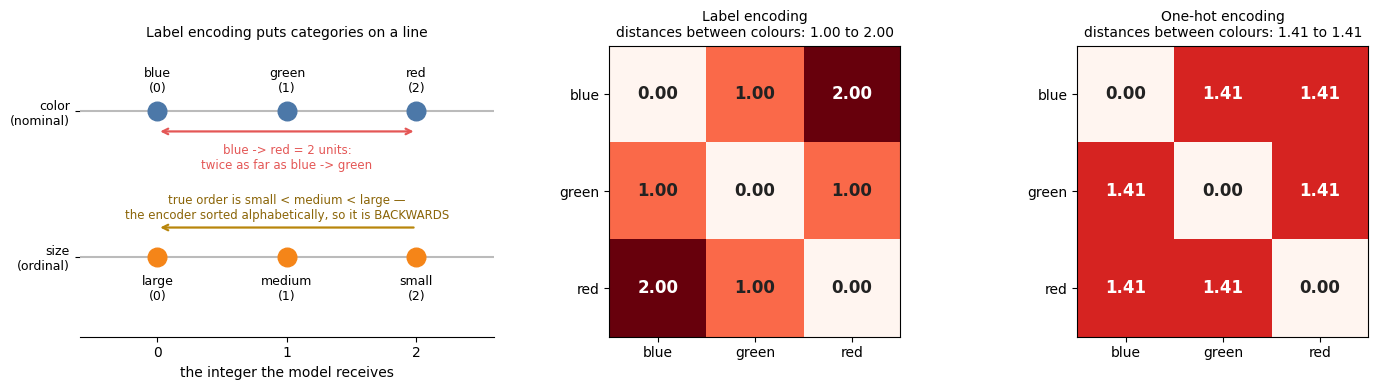

Distance between each pair of colours, as the model receives it:
            pair   label encoding    one-hot
    blue - green             1.00       1.41
      blue - red             2.00       1.41
     green - red             1.00       1.41

Label encoding: furthest pair 2.00, nearest pair 1.00 — a ratio of 2:1 that nobody measured.
One-hot       : every pair is 1.414 apart — no pair is closer than any other, which is the truth about colours.

Ordinal column 'size' encoded alphabetically: {'large': 0, 'medium': 1, 'small': 2}  <- the real order is reversed.


In [5]:
# 📊 FIGURE — the claim label encoding makes without telling you.
# WHAT: we take the two encodings already produced above and measure the DISTANCE
#       between categories that each one hands to a model. Linear models, k-NN, SVMs
#       and neural networks all consume exactly these distances.
# WHY: "label encoding invents an order" is easy to say and easy to nod at. Measured,
#      it stops being an opinion: blue-to-red becomes literally twice blue-to-green.
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.preprocessing import LabelEncoder

colour_enc = LabelEncoder().fit(df['color'])
colours = list(colour_enc.classes_)                    # alphabetical: blue, green, red
codes = colour_enc.transform(colours).astype(float)    # 0, 1, 2

size_enc = LabelEncoder().fit(df['size'])
sizes = list(size_enc.classes_)                        # alphabetical: large, medium, small
size_codes = size_enc.transform(sizes).astype(float)

# Distance a model actually sees, under each encoding.
d_label = np.abs(codes[:, None] - codes[None, :])
onehot = np.eye(len(colours))                          # one binary column per category
d_onehot = np.sqrt(((onehot[:, None, :] - onehot[None, :, :]) ** 2).sum(-1))

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(14.5, 4.0))

# --- A: what the integers claim, on a number line --------------------------
axA.axhline(1.0, color="#BBB", lw=1.5)
axA.axhline(0.0, color="#BBB", lw=1.5)
for c, x in zip(colours, codes):
    axA.scatter(x, 1.0, s=180, color="#4C78A8", zorder=3)
    axA.text(x, 1.13, f"{c}\n({int(x)})", ha="center", fontsize=9)
for s, x in zip(sizes, size_codes):
    axA.scatter(x, 0.0, s=180, color="#F58518", zorder=3)
    axA.text(x, -0.30, f"{s}\n({int(x)})", ha="center", fontsize=9)
axA.annotate("", xy=(0, 0.86), xytext=(2, 0.86),
             arrowprops=dict(arrowstyle="<->", color="#E45756", lw=1.6))
axA.text(1.0, 0.60, "blue -> red = 2 units:\ntwice as far as blue -> green",
         ha="center", fontsize=8.5, color="#E45756")
axA.annotate("", xy=(0, 0.20), xytext=(2, 0.20),
             arrowprops=dict(arrowstyle="->", color="#B8860B", lw=1.6))
axA.text(1.0, 0.26, "true order is small < medium < large —\n"
                    "the encoder sorted alphabetically, so it is BACKWARDS",
         ha="center", fontsize=8.5, color="#8B6508")
axA.set_xlim(-0.6, 2.6); axA.set_ylim(-0.55, 1.45)
axA.set_yticks([0, 1]); axA.set_yticklabels(["size\n(ordinal)", "color\n(nominal)"],
                                            fontsize=9)
axA.set_xticks([0, 1, 2]); axA.set_xlabel("the integer the model receives")
axA.set_title("Label encoding puts categories on a line", fontsize=10)
for spine in ("top", "right", "left"):
    axA.spines[spine].set_visible(False)

# --- B and C: the distance matrix each encoding hands to the model ---------
for ax, mat, name, vmax in ((axB, d_label, "Label encoding", 2.0),
                            (axC, d_onehot, "One-hot encoding", 2.0)):
    ax.imshow(mat, cmap="Reds", vmin=0, vmax=vmax)
    for r in range(len(colours)):
        for c in range(len(colours)):
            ax.text(c, r, f"{mat[r, c]:.2f}", ha="center", va="center", fontsize=12,
                    color="white" if mat[r, c] > vmax * 0.55 else "#222",
                    fontweight="bold")
    ax.set_xticks(range(len(colours))); ax.set_xticklabels(colours)
    ax.set_yticks(range(len(colours))); ax.set_yticklabels(colours)
    spread = mat[np.triu_indices(len(colours), 1)]
    ax.set_title(f"{name}\ndistances between colours: "
                 f"{spread.min():.2f} to {spread.max():.2f}", fontsize=10)

plt.tight_layout()
plt.show()

print("Distance between each pair of colours, as the model receives it:")
print(f"{'pair':>16}  {'label encoding':>15}  {'one-hot':>9}")
for a, b in combinations(range(len(colours)), 2):
    print(f"{colours[a] + ' - ' + colours[b]:>16}  {d_label[a, b]:>15.2f}  "
          f"{d_onehot[a, b]:>9.2f}")
print(f"\nLabel encoding: furthest pair {d_label.max():.2f}, nearest pair "
      f"{d_label[np.triu_indices(len(colours), 1)].min():.2f} — a ratio of "
      f"{d_label.max():.0f}:1 that nobody measured.")
print(f"One-hot       : every pair is {d_onehot[0, 1]:.3f} apart — no pair is "
      f"closer than any other, which is the truth about colours.")
print(f"\nOrdinal column 'size' encoded alphabetically: "
      f"{dict(zip(sizes, size_codes.astype(int).tolist()))}  <- the real order is reversed.")

### 👁️ Read the figure

**Left — the line nobody agreed to.** Once `color` becomes 0, 1, 2 the model is
looking at a ruler. The red arrow is the damage: **blue to red measures 2 and blue
to green measures 1**, so a linear model, a k-nearest-neighbour search or a neural
network will treat red as twice as far from blue as green is. Nobody wrote that
claim down and nothing printed a warning — it arrived with the integers.

The orange row underneath is the second failure, and it is the sneakier one.
`size` *does* have a real order, so label encoding is the **correct** method here.
`LabelEncoder` sorted alphabetically and produced `large=0, medium=1, small=2` —
the true order, reversed. Right method, wrong direction, no error message.

**Middle and right — the same three colours, measured.** These are the actual
distance matrices the two encodings hand to a model. Under label encoding the
off-diagonal values are **1.00, 2.00, 1.00**: three categories, two different
distances, an invented geometry. Under one-hot every off-diagonal cell reads
**1.41** — identical for every pair, which is the only honest statement about
colours: none of them is nearer to another.

**What this proves:** the two encodings are not "styles". They give the model
different *facts*. One-hot's uniform 1.41 is what nominal means; label encoding's
1-versus-2 is a measurement of something that does not exist. That is the exact
mechanism by which a nationality column, encoded as integers, becomes a variable a
model can order — the failure the Dutch childcare case at the top of this notebook
is built on.

**And the cost, visible in the printout above the figure:** three text columns
became **9** one-hot columns. Correct geometry is paid for in width, and a `city`
column with 300 values costs 300 columns for the same guarantee.

## 📊 What the two runs actually showed

Same five rows, same three text columns, one thing changed — the encoder:

| | what a category becomes | resulting columns | order implied? |
|---|---|---|---|
| **Label encoding** | one integer (`blue`→0, `green`→1, `red`→2) | **3** | **yes — and it is fictional** |
| **One-hot encoding** | one binary column per category | **9** | no |

**The conclusion these outputs support:** the two encoders carry exactly the same
information and make opposite trade-offs. Label encoding kept the table at 3
columns and inserted a claim nobody verified — that `red` (2) is twice `green` (1)
and further from `blue` (0). One-hot removed the claim and tripled the width, from
3 columns to 9, on a toy with only three categories per column.

Now scale it. A `city` column for Saudi Arabia has hundreds of values; a product
SKU column has tens of thousands. One-hot turns each into that many columns.
That is where this trade stops being an exercise.

**One thing the printout does not show:** `size` is `small / medium / large` —
genuinely ordered. Label encoding is the *right* choice there, and it happened to
map them 2 / 1 / 0, i.e. backwards, because `LabelEncoder` sorts alphabetically
and knows nothing about size. Correct method, wrong order, no error message.


titanic: full file, 891 rows.


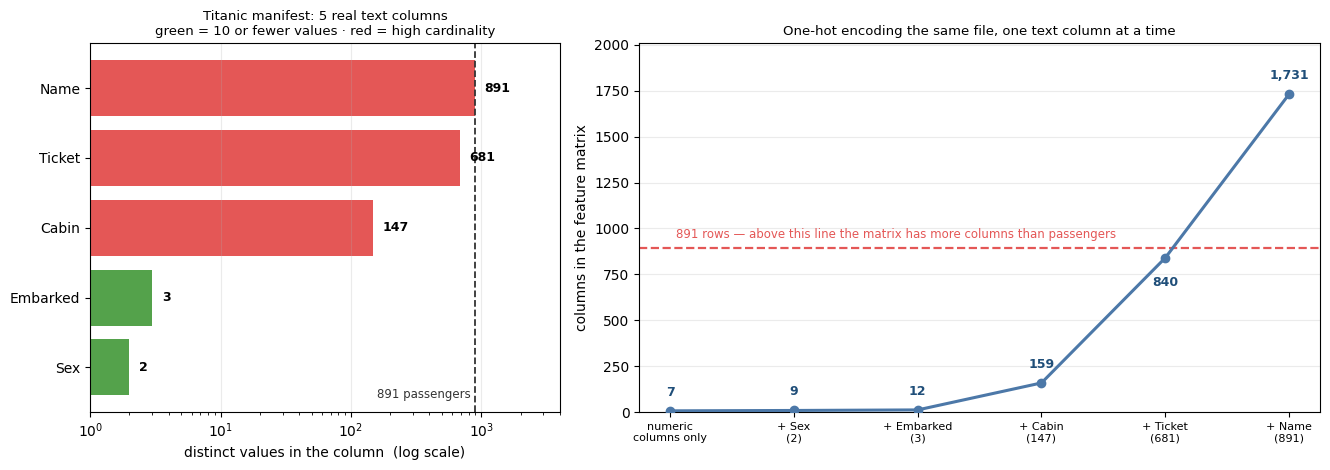

Titanic manifest as loaded          : 891 rows x 12 columns
Distinct values per text column     :
    Sex      :    2
    Embarked :    3
    Cabin    :  147
    Ticket   :  681
    Name     :  891

After pd.get_dummies on all 5 text columns: 891 rows x 1731 columns
Step-by-step width: 7 -> 9 -> 12 -> 159 -> 840 -> 1,731

Columns per row after full one-hot  : 1.94
Sex and Embarked cost 5 columns between them; Name, Ticket and Cabin cost 1,719.


In [6]:
# 📊 FIGURE — the cost side of the trade, measured on a real file instead of five rows.
# WHAT: we load the Titanic passenger manifest that ships with this diploma (891 real
#       passengers, 12 columns) and count the distinct values in each of its text
#       columns. Then we one-hot encode them one at a time, in order of cardinality,
#       and record how wide the feature matrix becomes at each step.
# WHY: on the toy above, one-hot cost 3 columns -> 9 and looked harmless. The rule
#      "one-hot scales with cardinality, not with rows" only becomes real when you
#      watch a 12-column file cross its own row count.
import pandas as pd
import matplotlib.pyplot as plt

tit = load("titanic")
text_cols = [c for c in tit.columns if tit[c].dtype == object]
card = tit[text_cols].nunique().sort_values()            # distinct values per text column
n_rows, n_cols = tit.shape

# --- WHAT: encode one text column at a time and record the resulting width ---
numeric_only = [c for c in tit.columns if c not in text_cols]
width, steps, labels = len(numeric_only), [len(numeric_only)], ["numeric\ncolumns only"]
for col in card.index:
    width = width - 0 + tit[col].nunique()               # the column's categories become columns
    steps.append(width)
    labels.append(f"+ {col}\n({tit[col].nunique()})")

# Cross-check the arithmetic against what pandas actually produces.
onehot_all = pd.get_dummies(tit, columns=text_cols)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.4, 4.8),
                               gridspec_kw={"width_ratios": [1, 1.45]})

# --- LEFT: how many distinct values each real text column holds -------------
bars = axL.barh(card.index, card.values,
                color=["#54A24B" if v <= 10 else "#E45756" for v in card.values])
for b, v in zip(bars, card.values):
    axL.text(v * 1.18, b.get_y() + b.get_height() / 2, f"{v}", va="center",
             fontsize=9, fontweight="bold")
axL.set_xscale("log")                      # 2 and 891 on one axis needs a log scale
axL.axvline(n_rows, color="#333", ls="--", lw=1.3)
axL.text(n_rows * 0.93, -0.44, f"{n_rows} passengers", ha="right", fontsize=8.5, color="#333")
axL.set_xlim(1, 4000)
axL.set_xlabel("distinct values in the column  (log scale)")
axL.set_title("Titanic manifest: 5 real text columns\n"
              "green = 10 or fewer values · red = high cardinality",
              fontsize=9.5)
axL.grid(axis="x", alpha=0.25)

# --- RIGHT: the feature matrix getting wider, one column at a time ----------
axR.plot(range(len(steps)), steps, marker="o", color="#4C78A8", lw=2.2, zorder=3)
for i, v in enumerate(steps):
    # Keep the count off the 891-row line where the two would otherwise touch.
    dy = -20 if abs(v - n_rows) < 0.09 * max(steps) else 11
    axR.annotate(f"{v:,}", (i, v), textcoords="offset points", xytext=(0, dy),
                 ha="center", fontsize=9, fontweight="bold", color="#1F4E79")
axR.axhline(n_rows, color="#E45756", ls="--", lw=1.6)
axR.text(0.05, n_rows + 55, f"{n_rows} rows — above this line the matrix has more "
                            f"columns than passengers", fontsize=8.5, color="#E45756")
axR.set_xticks(range(len(steps)))
axR.set_xticklabels(labels, fontsize=8)
axR.set_ylabel("columns in the feature matrix")
axR.set_ylim(0, max(steps) * 1.16)
axR.set_title("One-hot encoding the same file, one text column at a time", fontsize=9.5)
axR.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Titanic manifest as loaded          : {n_rows} rows x {n_cols} columns")
print("Distinct values per text column     :")
for c, v in card.items():
    print(f"    {c:9s}: {v:4d}")
print(f"\nAfter pd.get_dummies on all 5 text columns: "
      f"{onehot_all.shape[0]} rows x {onehot_all.shape[1]} columns")
print(f"Step-by-step width: " + " -> ".join(f"{s:,}" for s in steps))
print(f"\nColumns per row after full one-hot  : {onehot_all.shape[1] / n_rows:.2f}")
print("Sex and Embarked cost 5 columns between them; Name, Ticket and Cabin cost "
      f"{card['Name'] + card['Ticket'] + card['Cabin']:,}.")


### 👁️ Read the figure

The toy above cost 3 columns → 9 and looked like a rounding error. This is the same
rule applied to a real file: **891 passengers, 12 columns, five of them text.**

**Left — cardinality is the whole story, and it is not a property you can guess.**
The axis is logarithmic because `Sex` has **2** distinct values and `Name` has **891**
and both have to fit on one picture. Two green bars, three red ones. `Sex` and
`Embarked` are exactly the shape the five-row toy prepared you for. `Cabin` (**147**),
`Ticket` (**681**) and `Name` (**891**) are a different animal living in the same file.

**Right — the feature matrix widening, one column at a time.** Start with the seven
numeric columns. `Sex` adds 2, `Embarked` adds 3 — after both, the matrix is **12**
columns wide and nothing has gone wrong. Then `Cabin` takes it to **159**, `Ticket` to
**840**, and `Name` to **1,731**. The red dashed line is the number of *passengers*.
The final matrix has **1,731 columns for 891 rows** — nearly two columns per row —
and `pd.get_dummies` produced it without a warning, in under a second.

**Look at `Name` specifically: 891 distinct values in 891 rows.** One-hot encoding it
builds a column that is 1 for exactly one passenger and 0 for the other 890 — an
identity matrix. A linear model can fit that perfectly and has learned nothing except
who was on the boat. This is the shape of pure memorisation, and it arrived from
mechanically applying a correct rule ("nominal columns get one-hot encoding") to a
column that should never have been a feature.

**What this proves:** "label encoding for ordinal, one-hot for nominal" is a real rule
and it is not sufficient. Before you pick an encoder, count the distinct values —
`df.nunique()` is one line — and decide whether the column is a *category* at all or
just an identifier wearing text. `Sex` and `Embarked` here are categories. `Ticket`
and `Name` are names for individual people, and the alternatives listed in "Where this
breaks" below (grouping rare values, target encoding, hashing, embeddings) exist for
the middle case, `Cabin`.

## 💬 Discuss

1. Of our three columns — `color`, `size`, `category` — exactly one has a real
   order. **Which encoder would you choose for each, and how would you fix the
   alphabetical ordering `LabelEncoder` imposed on `size`?** Write the mapping you
   would use.
2. At prediction time a new row arrives with `color = "yellow"`, a value that was
   never in the training data. Trace what each encoder does. Which failure would
   you rather debug at 2 a.m., and what would you have built to make it loud?
3. **Regional practice:** you are building a loan model for a Saudi bank and the
   data includes `nationality` and `city_of_residence`. For each, argue whether it
   belongs in the model at all — and if it does, how you would encode it and what
   you would monitor afterwards. Assume someone will ask you to justify a refusal
   to a customer.


## Summary

This notebook covered:
- ✅ **Label Encoding**: Assigns integer labels to categories
- ✅ **One-Hot Encoding**: Creates binary columns for each category
- ✅ **When to use**: Label encoding for ordinal data, one-hot for nominal data

Categorical encoding is essential for preparing data for machine learning models.

## ⚠️ Where this breaks

- **Label encoding invents an order and most models believe it.** Linear and
  logistic regression, SVMs, k-nearest neighbours and neural networks all treat
  the integers as magnitudes: `red = 2` really is "twice" `green = 1` to them.
  Tree-based models are the exception — they only ever split on thresholds, so an
  arbitrary integer mapping mostly costs them a few extra splits. **The rule:**
  label-encode only for tree models, or for genuinely ordinal columns with the
  order set by hand.
- **`LabelEncoder` sorts alphabetically.** `large / medium / small` → 0 / 1 / 2 is
  the reverse of the real order, and nothing tells you. For ordinal columns, use
  an explicit mapping (`{'small': 0, 'medium': 1, 'large': 2}`) or
  `OrdinalEncoder(categories=[...])` where you supply the sequence.
- **One-hot encoding scales with cardinality, not with rows.** Hundreds of
  categories means hundreds of columns, most of them almost always zero — which
  costs memory, slows training, and gives linear models very little data per
  coefficient. **Cheaper alternatives:** group rare categories into "other";
  target/mean encoding with careful cross-fitted folds; hashing; or learned
  embeddings for very high cardinality.
- **Unseen categories break both encoders at prediction time.** `LabelEncoder`
  raises on a value it has not seen; `pd.get_dummies` silently produces a
  different set of columns than training did, which is worse. **Use instead:**
  `sklearn.preprocessing.OneHotEncoder(handle_unknown='ignore')` inside a
  `Pipeline`, so training and serving share one fitted object.
- **`get_dummies` fitted on the test set is a bug factory.** Run it separately on
  train and test and you get different columns whenever a category is missing from
  one of them. Fit the encoder once, on training data, and apply it.
- **The dummy-variable trap.** For a plain linear regression with an intercept,
  *k* one-hot columns are perfectly collinear; drop one (`drop_first=True`).
  Regularised models and trees do not care.
- **Encoding cannot make a variable appropriate.** The Dutch system's failure was
  not that nationality was encoded badly. It was that nationality was in the model
  at all. Choose the columns before you choose the encoder.


## 📚 References

1. Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830. <https://arxiv.org/abs/1201.0490>
2. Micci-Barreca, D. (2001). *A Preprocessing Scheme for High-Cardinality Categorical Attributes in Classification and Prediction Problems*. ACM SIGKDD Explorations, 3(1), 27–32.
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Ch. 3 (qualitative predictors). Springer.
4. Grinsztajn, L., Flöge, K., Key, O., et al. (2026). *TabPFN-3: Technical Report*. arXiv. <https://arxiv.org/abs/2605.13986>
5. Liang, H., Ma, X., Liu, Z., et al. (2025). *DataFlow: An LLM-Driven Framework for Unified Data Preparation and Workflow Automation in the Era of Data-Centric AI*. arXiv. <https://arxiv.org/abs/2512.16676>